Here we have the imports needed

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import random
import yaml
from scipy.integrate import quad
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from scipy.optimize import minimize
import scipy.stats as stats


We extract our dataset

\Points: 22   z ∈ [0.140, 0.980]
WOrkspace range: [0.0700, 1.0000]

      z    (1/N)dN/dz           σ    σ/y [%]
----------------------------------------------
 0.1400      0.116000    0.030676       26.4%
 0.1800      0.198000    0.037135       18.8%
 0.2200      0.247000    0.030561       12.4%
 0.2600      0.264000    0.028983       11.0%
 0.3000      0.308000    0.032171       10.4%
 0.3400      0.370000    0.032909        8.9%
 0.3800      0.426000    0.034713        8.1%
 0.4200      0.501000    0.038419        7.7%
 0.4600      0.577000    0.040927        7.1%
 0.5000      0.685000    0.041785        6.1%
 0.5400      0.833000    0.052811        6.3%
 0.5800      1.055000    0.074061        7.0%
 0.6200      1.311000    0.089039        6.8%
 0.6600      1.667000    0.087892        5.3%
 0.7000      2.080000    0.084119        4.0%
 0.7400      2.566000    0.116263        4.5%
 0.7800      2.934000    0.178037        6.1%
 0.8200      3.104000    0.234949        7.6%
 0.8600     

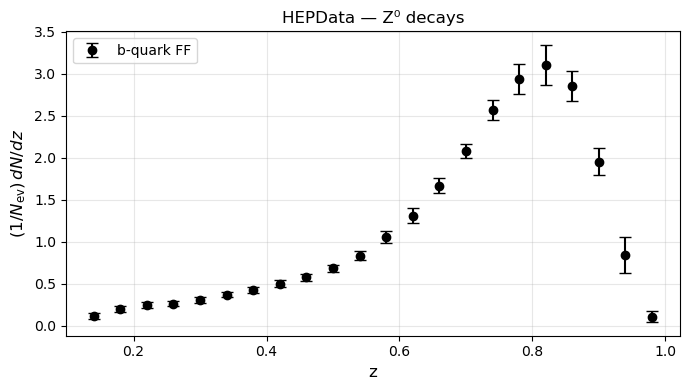

In [2]:
YAML_FILE="Table1.yaml"


def load_hepdata_yaml(filepath):
    """Load the HEPData dataset.
    REturns z_data, y_data, sigma_data.
    """
    with open(filepath, 'r') as f:
        raw = yaml.safe_load(f)

    #momentum fraction z
    indep = raw['independent_variables'][0]
    
    z_data = []
    for pt in indep['values']:
        if 'value' in pt:
            z_data.append(float(pt['value']))
        elif 'low' in pt and 'high' in pt:
            z_data.append(0.5 * (float(pt['low']) + float(pt['high'])))
        else:
            raise ValueError(f"unexpected format: {pt}")
    z_data = np.array(z_data)

    # (1/N) dN/dx
    dep = raw['dependent_variables'][0]

    y_data, sigma_data = [], []
    for pt in dep['values']:
        y_data.append(float(pt['value']))
        err_sq = 0.0
        for err in pt.get('errors', []):
            if 'symerror' in err:
                err_sq += float(err['symerror'])**2
            elif 'asymerror' in err:
                up = abs(float(err['asymerror'].get('plus',  0)))
                dn = abs(float(err['asymerror'].get('minus', 0)))
                err_sq += ((up + dn) / 2.0)**2
        sigma_data.append(max(np.sqrt(err_sq), 1e-6))

    return z_data, np.array(y_data), np.array(sigma_data)

z_data, y_data, sigma_data = load_hepdata_yaml(YAML_FILE)


Z_MIN = max(z_data.min() * 0.5, 1e-4)  
Z_MAX = min(z_data.max() * 1.05, 1)

print(f"\Points: {len(z_data)}   z ∈ [{z_data.min():.3f}, {z_data.max():.3f}]")
print(f"WOrkspace range: [{Z_MIN:.4f}, {Z_MAX:.4f}]")
print(f"\n{'z':>7}  {'(1/N)dN/dz':>12}  {'σ':>10}  {'σ/y [%]':>9}")
print("-" * 46)
for z, y, s in zip(z_data, y_data, sigma_data):
    print(f"{z:7.4f}  {y:12.6f}  {s:10.6f}  {100*s/max(abs(y),1e-9):9.1f}%")

plt.figure(figsize=(7, 4))
plt.errorbar(z_data, y_data, yerr=sigma_data,
             fmt='ko', capsize=4, label='b-quark FF')
plt.xlabel('z', fontsize=12)
plt.ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
plt.title('HEPData — Z⁰ decays')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



We define our variables that define our phase space and the number of qubits needed

In [ ]:
PARAM_NAMES      = ['N', 'epsilon', 'alpha']


PARAM_MIN        = np.array([0.388,  0.0270, 0.0])
PARAM_MAX        = np.array([0.488,   0.0470 , 0.02])
N_PARAMS         = 3
QUBITS_PER_PARAM = 5
NUM_QUBITS       = N_PARAMS * QUBITS_PER_PARAM   

print(f"REsolution: 2^{QUBITS_PER_PARAM} = {2**QUBITS_PER_PARAM} values per parameter")
for name, lo, hi in zip(PARAM_NAMES, PARAM_MIN, PARAM_MAX):
    step = (hi - lo) / (2**QUBITS_PER_PARAM-1)
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]   step = {step:.6f}")



def peterson_mod(z, N, epsilon, alpha):
    """D(z; N, ε) = N / [z * (1+alpha - 1/z - ε/(1-z))²]
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    denom_inner = 1.0+ alpha- 1.0/z - epsilon/(1.0 - z)
    denom = z * denom_inner**2
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
    return np.maximum(val, 0.0)   # FF is positive


def bowler(z, N, a, b):
    """D(z; N, a, b) = (N / z^(1+b)) * (1-z)^a * e^(-b/z)"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = (N / (z**(1.0 + b))) * ((1.0 - z)**a) * np.exp(-b / z)
        val = np.where(np.isfinite(val), val, 0.0)
    return np.maximum(val, 0.0)

def lund(z, N, a, b):
    """D(z; N, a, b) = (N / z) * (1-z)^a * e^(-b/z)"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = (N / z) * ((1.0 - z)**a) * np.exp(-b / z)
        val = np.where(np.isfinite(val), val, 0.0)
    return np.maximum(val, 0.0)

def f1(z, N, c, d):
    """D(z; N, c, d) = N * ((1-z)/z) * (1 - c/z - d/(1-z))^-2"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    denom_inner = 1.0 - c/z - d/(1.0 - z)
    denom = denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N * ((1.0 - z) / z) / denom, 0.0)
    return np.maximum(val, 0.0)

def f2(z, N, c, d):
    """D(z; N, c, d) = (N/z) * (1 - c/z - d/(1-z))^-2"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    denom_inner = 1.0 - c/z - d/(1.0 - z)
    denom = z * denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
    return np.maximum(val, 0.0)

def power_function(z, N, alpha, beta):
    """D(z; N, alpha, beta) = N * z^alpha * (1-z)^beta"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    val = N * (z**alpha) * ((1.0 - z)**beta)
    return np.maximum(val, 0.0)


def ff_model(z, theta):
    N, epsilon_b, alpha = theta
    if N <= 0 :
        return np.zeros_like(np.asarray(z, dtype=float))
    return peterson_mod(z, N, epsilon_b, alpha)


def chi2_ff(theta):
    """χ²(θ) = Σ [(D̃_modell - y)² / σ²]"""
    f = ff_model(z_data, theta)
    if not np.all(np.isfinite(f)):
        return 1e12
    chi2 = float(np.sum(((f - y_data) / sigma_data)**2))
    return chi2 if np.isfinite(chi2) else 1e12



print("Min values of the parameters (N, r) and the corresponding χ²:")
res = minimize(chi2_ff, x0=[0.5, 0.05, 0.0],  method='L-BFGS-B')
C_min = res.fun
N_Exact=res.x[0]
r_Exact=res.x[1]
alpha_Exact=res.x[2]
chi2_acceptable = C_min + 2.3 

print(f"Theoretical minimum (C_min): {C_min:.4f}")
print(f"Acceptable threshold: {chi2_acceptable:.4f}")
print(f"Optimal parameters: N = {N_Exact:.4f}, r = {r_Exact:.4f}")


def collins_spiller(z, N, epsilon_b):
    """
    Modelo de Collins-Spiller
    Parámetros: N, epsilon_b
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    term1 = (1.0 - z) / z + ((2.0 - z) * epsilon_b) / (1.0 - z)
    term2 = 1.0 + z**2
    denom_inner = 1.0 - 1.0/z - epsilon_b/(1.0 - z)
    denom = denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N * term1 * term2 / denom, 0.0)
    
    return np.maximum(val, 0.0)


def Peterson(z, N, epsilon_b):
    """
    Modelo de Peterson et al.
    Parámetros: N, epsilon_b
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    denom_inner = 1.0 - 1.0/z - epsilon_b/(1.0 - z)
    denom = z * denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
        
    return np.maximum(val, 0.0)


def Kartvelishvili(z, N, alpha_b):
    """
    Modelo  de Kartvelishvili
    Parámetros: N, alpha_b
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    # Expresión D(x_b) = N * x_b^(alpha_b) * (1 - x_b)
    val = N * (z**alpha_b) * (1.0 - z)
    return np.maximum(val, 0.0)




def Braaten(z, N, r):
    """
    Modelo de Braaten D_{Q->V} (mesones vectoriales)
    Parámetros: N, r
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    # Coeficientes del polinomio interior
    term0 = 2.0
    term1 = -2.0 * (3.0 - 2.0*r)
    term2 = 3.0 * (3.0 - 2.0*r + 4.0*(r**2))
    term3 = -2.0 * (1.0 - r) * (4.0 - r + 2.0*(r**2))
    term4 = ((1.0 - r)**2) * (3.0 - 2.0*r + 2.0*(r**2))
    
    poly = term0 + term1*z + term2*(z**2) + term3*(z**3) + term4*(z**4)
    
    # Atención al factor 3N de la ecuación vectorial
    numerator = 3.0 * N * z * ((1.0 - z)**2) * poly
    denom = (1.0 - (1.0 - r)*z)**6
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, numerator / denom, 0.0)
        
    return np.maximum(val, 0.0)


REsolution: 2^5 = 32 values per parameter
  N       : [0.3880, 0.4880]   step = 0.003226
  epsilon : [0.0270, 0.0470]   step = 0.000645
  alpha   : [0.0000, 0.0200]   step = 0.000645
Min values of the parameters (N, r) and the corresponding χ²:
Theoretical minimum (C_min): 40.0082
Acceptable threshold: 42.3082
Optimal parameters: N = 0.4406, r = 0.0368


Backend (not noise in 3 param yet)

In [4]:
def get_backend():
    return AerSimulator()

Quantum operators

In [5]:
K_ENTANGLED = 5
def initialize_chromosome(num_qubits):
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))

    msb_indices = []
    for p in range(N_PARAMS):
        start_idx = p * QUBITS_PER_PARAM
        msb_indices.extend(range(start_idx, start_idx + K_ENTANGLED))

    for i in range(len(msb_indices)):
        for j in range(i + 1, len(msb_indices)):
            qc.cx(msb_indices[i], msb_indices[j])

    qc.barrier()
    return qc


def measure_chromosome(qc, backend):

    qc_m = qc.copy()
    qc_m.measure_all()
    qc_m   = transpile(qc_m, backend)
    counts = backend.run(qc_m, shots=1).result().get_counts()
    return list(counts.keys())[0][::-1]   

def decode_parameters(binary_string):

    max_int = (2 ** QUBITS_PER_PARAM) - 1   
    params  = []
    for k in range(N_PARAMS):
        chunk   = binary_string[k * QUBITS_PER_PARAM : (k + 1) * QUBITS_PER_PARAM]
        int_val = int(chunk, 2)             
        val     = PARAM_MIN[k] + (PARAM_MAX[k] - PARAM_MIN[k]) * (int_val / max_int)
        params.append(val)
    return np.array(params)


def apply_rotation(qc, best_binary, rotation_angle):
    """
      best_bit = 1 → RY(+θ)  (grows P(|1⟩))
      best_bit = 0 → RY(−θ)  (grows P(|0⟩))
    """
    for i in range(qc.num_qubits):
        if i >= len(best_binary):
            continue
        direction = +1 if int(best_binary[i]) == 1 else -1
        qc.ry(direction * rotation_angle, i)

    msb_indices = []
    for p in range(N_PARAMS):
        start_idx = p * QUBITS_PER_PARAM
        msb_indices.extend(range(start_idx, start_idx + K_ENTANGLED))

    for i in range(len(msb_indices)):
        for j in range(i + 1, len(msb_indices)):
            qc.cx(msb_indices[i], msb_indices[j])
            
    return qc


def apply_mutation(qc, mutation_rate):
    
    qc.barrier()
    for i in range(qc.num_qubits):
        if random.random() < mutation_rate:
            qc.y(i)
    return qc

In [ ]:
from qiskit.quantum_info import Statevector, partial_trace


def analyze_entanglement_C(population, param_index=0, qubits_per_param=5):
    
    nonpurities = []
    
    for qc in population:
        state = Statevector(qc)
        
        start_q = param_index * qubits_per_param
        end_q = start_q + qubits_per_param
        param_qubits = list(range(start_q, end_q))
        
        trace_qubits = [q for q in range(qc.num_qubits) if q not in param_qubits]
        rho_reduced = partial_trace(state, trace_qubits)
        
        purity = np.real(rho_reduced.purity())
        C = abs(1.0 - purity)
        nonpurities.append(C)
        
    return np.mean(nonpurities)

In [7]:
def run_qga(generations=20, population_size=10,
            rotation_angle=0.05, mutation_rate=0.15):
   
    backend    = get_backend()
    population = [initialize_chromosome(NUM_QUBITS)
                  for _ in range(population_size)]

    best_chi2   = float('inf')
    best_binary = None
    best_theta  = np.array([1.0, 0.006, 0.0001])  
    history     = []
    
    stagnation_counter = 0
    current_rot_angle = rotation_angle
    current_mut_rate = mutation_rate

    print(f"QGA — Modified Peterson | {NUM_QUBITS} qubits | "
          f"pop={population_size} | gens={generations}")
    print("=" * 60)

    historial_C_N = []
    historial_C_epsilon = []
    historial_C_alpha = []

    for gen in range(generations):
        gen_best_chi2   = float('inf')
        gen_best_binary = None
        improved_this_gen = False

        for qc in population:
            binary = measure_chromosome(qc, backend)
            theta  = decode_parameters(binary)
            chi2   = chi2_ff(theta)

            if chi2 < gen_best_chi2:
                gen_best_chi2   = chi2
                gen_best_binary = binary

            if chi2 < best_chi2:
                best_chi2   = chi2
                best_binary = binary
                best_theta  = theta.copy()
                improved_this_gen = True

        history.append(best_chi2)

        if improved_this_gen:
            stagnation_counter = 0  
        else:
            stagnation_counter += 1 

        if stagnation_counter >= 4:
            current_mut_rate = min(0.30, current_mut_rate * 1.25)
            
            print(f" [!] Stagnation. Adjusting parameters -> Angle: {current_rot_angle:.4f}, Mutation: {current_mut_rate:.4f}")
            stagnation_counter = 0 

        if gen_best_binary:
            for i in range(len(population)):
                population[i] = apply_rotation(
                    population[i], gen_best_binary, current_rot_angle)
                population[i] = apply_mutation(
                    population[i], current_mut_rate)

        print(f"Gen {gen+1:03d}: χ² = {best_chi2:9.4f}  "
              f"N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}   α = {best_theta[2]:.5f}")


        C_N = analyze_entanglement_C(population, param_index=0, qubits_per_param=QUBITS_PER_PARAM)
        C_eps = analyze_entanglement_C(population, param_index=1, qubits_per_param=QUBITS_PER_PARAM)
        C_alpha = analyze_entanglement_C(population, param_index=2, qubits_per_param=QUBITS_PER_PARAM)
    
        historial_C_N.append(C_N)
        historial_C_epsilon.append(C_eps)
        historial_C_alpha.append(C_alpha)

    print("=" * 60)
    
    return best_chi2, best_theta, population, history, best_binary, historial_C_N, historial_C_epsilon, historial_C_alpha


In [ ]:
best_chi2, best_theta, pop, history, best_binary, historial_C_N, historial_C_epsilon, historial_C_alpha = run_qga(
    generations = 20,
    population_size = 10,
    rotation_angle = 0.05,
    mutation_rate = 0.15
)


Classical genetic algorithm using the same bits as qubits in the quantum.


In [8]:
def cga_random_individual():
    return ''.join(random.choice('01') for _ in range(NUM_QUBITS))


def cga_tournament_select(population, fitnesses, k=3):
    contestants = random.sample(range(len(population)), k)
    winner = min(contestants, key=lambda i: fitnesses[i])
    return population[winner]


def cga_two_point_crossover(parent_a, parent_b):
    if random.random() > 0.5:
        return parent_a, parent_b
    n = len(parent_a)
    p1, p2 = sorted(random.sample(range(1, n), 2))
    child_a = parent_a[:p1] + parent_b[p1:p2] + parent_a[p2:]
    child_b = parent_b[:p1] + parent_a[p1:p2] + parent_b[p2:]
    return child_a, child_b


def cga_mutate(individual, mutation_rate):
    flipped = []
    for bit in individual:
        if random.random() < mutation_rate:
            flipped.append('1' if bit == '0' else '0')
        else:
            flipped.append(bit)
    return ''.join(flipped)


def run_cga(generations=20, population_size=10, mutation_rate=0.15,
            tournament_k=3, seed=None):
   
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    #Initialization
    population = [cga_random_individual() for _ in range(population_size)]

    best_chi2  = float('inf')
    best_theta = np.array([1.0, 0.006, 0.0001])
    history    = []

    print(f"CGA — Peterson | {NUM_QUBITS} bits | "
          f"pop={population_size} | gens={generations} | "
          f"mut={mutation_rate}")

    for gen in range(generations):

        
        fitnesses = []
        for ind in population:
            theta = decode_parameters(ind)   
            fitnesses.append(chi2_ff(theta))

        
        gen_best_idx = int(np.argmin(fitnesses))
        if fitnesses[gen_best_idx] < best_chi2:
            best_chi2  = fitnesses[gen_best_idx]
            best_theta = decode_parameters(population[gen_best_idx]).copy()
        history.append(best_chi2)

        
        elite      = population[gen_best_idx]   
        next_gen   = [elite]

        while len(next_gen) < population_size:
            parent_a = cga_tournament_select(population, fitnesses, tournament_k)
            parent_b = cga_tournament_select(population, fitnesses, tournament_k)
            child_a, child_b = cga_two_point_crossover(parent_a, parent_b)
            next_gen.append(cga_mutate(child_a, mutation_rate))
            if len(next_gen) < population_size:
                next_gen.append(cga_mutate(child_b, mutation_rate))

        population = next_gen

        print(f"Gen {gen+1:03d}: chi2 = {best_chi2:9.4f}  "
              f"N = {best_theta[0]:.4f}   eps = {best_theta[1]:.5f}   alpha = {best_theta[2]:.5f}")

    print("=" * 60)
    print(f"chi2_CGA  = {best_chi2:.6f}   chi2/n = {best_chi2/len(z_data):.4f}")
    print(f"N         = {best_theta[0]:.6f}")
    print(f"eps       = {best_theta[1]:.6f}")
    print(f"alpha     = {best_theta[2]:.6f}")

    return best_chi2, best_theta, history


#cga_chi2, cga_theta, cga_history = run_cga(
#    generations     = 20,
#    population_size = 10,
#    mutation_rate   = 0.03,
#    tournament_k    = 3,
#    seed            = 42
#)


In [ ]:
best_qc = pop[0]

print("Final cirquit")
print(f"  gates    : {best_qc.size()}")
print(f"  deep: {best_qc.depth()}")
print(f"  binary chain: {best_binary}")
print(f"  N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}")

fig2 = best_qc.draw(output='mpl', style='iqp', fold=40, scale=0.50)
fig2.set_size_inches(100, 75)
plt.tight_layout()
plt.show()


QGA vs CGA  single run


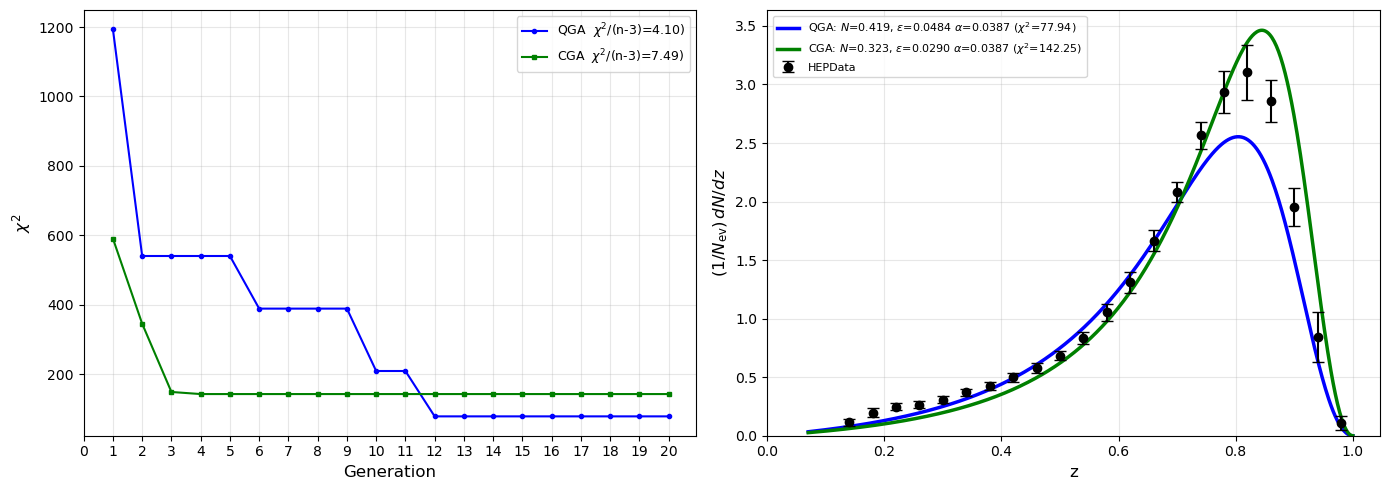


Method              N    epsilon      alpha       chi2 chi2/n-3
-----------------------------------------------------------------
CGA            0.3226    0.02903    0.03871   142.2455   7.4866
QGA            0.4194    0.04839    0.03871    77.9376   4.1020


In [10]:
n_pts = len(z_data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gen_axis_qga = np.arange(1, len(history)     + 1)
gen_axis_cga = np.arange(1, len(cga_history) + 1)

axes[0].plot(gen_axis_qga, history,     'b-o', markersize=3, lw=1.5,
             label=f'QGA  $\chi^2$/(n-3)={best_chi2/(n_pts-3):.2f})')
axes[0].plot(gen_axis_cga, cga_history, 'g-s', markersize=3, lw=1.5,
             label=f'CGA  $\chi^2$/(n-3)={cga_chi2/(n_pts-3):.2f})')

axes[0].set_xlabel('Generation', fontsize=12)
axes[0].set_ylabel(r'$\chi^2$', fontsize=12)
valores_x = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
axes[0].set_xticks(valores_x)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

z_fine    = np.linspace(Z_MIN, Z_MAX, 500)
f_qga_    = ff_model(z_fine, best_theta)
f_cga_    = ff_model(z_fine, cga_theta)

axes[1].errorbar(z_data, y_data, yerr=sigma_data,
                 fmt='ko', capsize=4, label='HEPData', zorder=5)
axes[1].plot(z_fine, f_qga_, 'b-',  lw=2.5,
             label=(rf'QGA: $N$={best_theta[0]:.3f}, '
                    rf'$\varepsilon$={best_theta[1]:.4f} '
                    rf'$\alpha$={best_theta[2]:.4f} '
                    rf'($\chi^2$={best_chi2:.2f})'))
axes[1].plot(z_fine, f_cga_, 'g-',  lw=2.5,
             label=(rf'CGA: $N$={cga_theta[0]:.3f}, '
                    rf'$\varepsilon$={cga_theta[1]:.4f} '
                    rf'$\alpha$={cga_theta[2]:.4f} '
                    rf'($\chi^2$={cga_chi2:.2f})'))


axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].set_xlim(left=0); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n" + "=" * 65)
print(f"{'Method':<12} {'N':>8} {'epsilon':>10} {'alpha':>10} {'chi2':>10} {'chi2/n-3':>8}")
print("-" * 65)

for label, th, chi2 in [
        ('CGA',       cga_theta,  cga_chi2),
        ('QGA',       best_theta, best_chi2)]:
    print(f"{label:<12} {th[0]:>8.4f} {th[1]:>10.5f} {th[2]:>10.5f} {chi2:>10.4f} {chi2/(n_pts-3):>8.4f}")
print("=" * 65)


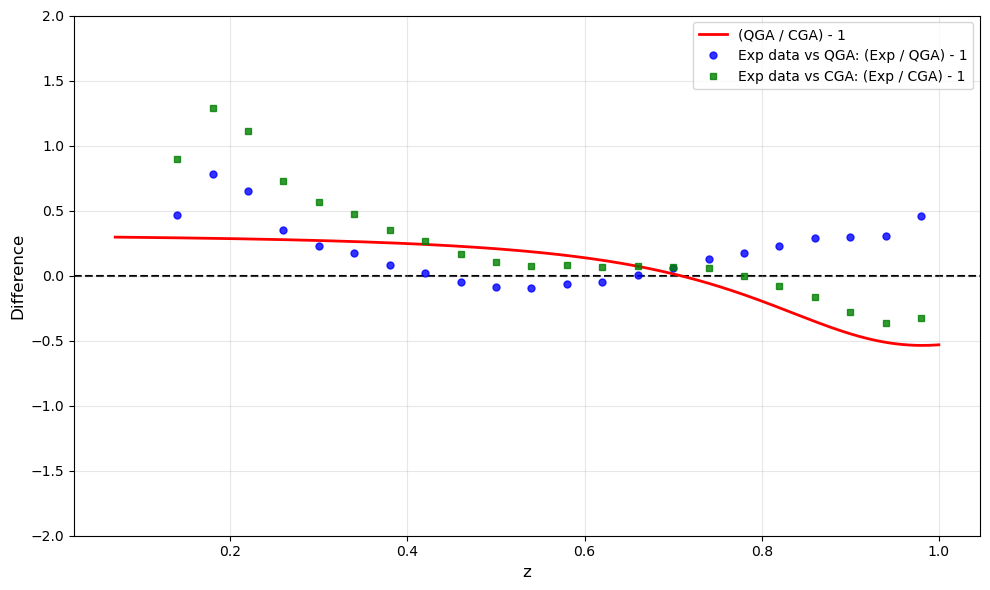

In [11]:
z_fine = np.linspace(Z_MIN, Z_MAX, 500)
f_qga_fine = ff_model(z_fine, best_theta)
f_cga_fine = ff_model(z_fine, cga_theta)

ratio_models = np.divide(f_qga_fine, f_cga_fine, out=np.zeros_like(f_qga_fine), where=(f_cga_fine != 0)) - 1

f_qga_pts = ff_model(z_data, best_theta)
f_cga_pts = ff_model(z_data, cga_theta)

res_qga = np.divide(y_data, f_qga_pts, out=np.zeros_like(y_data), where=(f_qga_pts != 0)) - 1
res_cga = np.divide(y_data, f_cga_pts, out=np.zeros_like(y_data), where=(f_cga_pts != 0)) - 1

plt.figure(figsize=(10, 6))

plt.axhline(0, color='black', linestyle='--', lw=1.5, zorder=1)

plt.plot(z_fine, ratio_models, 'r-', lw=2, label='(QGA / CGA) - 1', zorder=2)

plt.plot(z_data, res_qga, 'bo', markersize=5, alpha=0.8,
         label='Exp data vs QGA: (Exp / QGA) - 1', zorder=3)

plt.plot(z_data, res_cga, 'gs', markersize=5, alpha=0.8,
         label='Exp data vs CGA: (Exp / CGA) - 1', zorder=4)

plt.xlabel('z', fontsize=12)
val_y = [2,1.5,1,0.5,0,-0.5,-1,-1.5,-2]
plt.yticks(val_y)
plt.ylabel('Difference', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

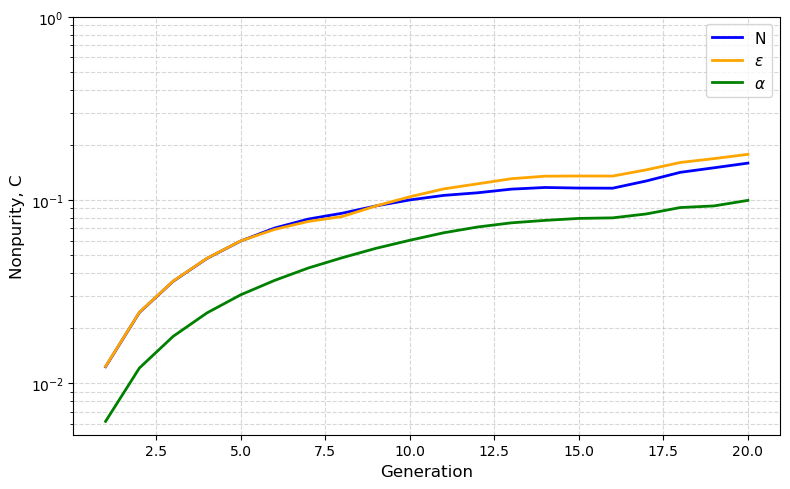

In [12]:
plt.figure(figsize=(8, 5))

generaciones_eje_x = range(1, len(historial_C_N) + 1)

plt.plot(generaciones_eje_x, historial_C_N, label='N', color='blue', lw=2)
plt.plot(generaciones_eje_x, historial_C_epsilon, label=r'$\epsilon$', color='orange', lw=2)
plt.plot(generaciones_eje_x, historial_C_alpha, label=r'$\alpha$', color='green', lw=2)

plt.yscale('log')
valores_y = [10**0, 10**-1, 10**-2]
plt.yticks(valores_y)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Nonpurity, C', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

100 runs loop 

In [ ]:
import pickle
import numpy as np
import os

model_configs_3p = {
    "F2": {
        "func": f2,
        "ranges": {
            "Medium": {"p1": [0.34, 0.54], "p2": [0.90, 1.10], "p3": [0.01, 0.06]},
            "Small":  {"p1": [0.39, 0.49], "p2": [0.95, 1.05], "p3": [0.02, 0.05]}
        }
    }
}

current_model_func_3p = None

def ff_model(z, theta):
    N, param2, param3 = theta
    if N <= 0:
        return np.zeros_like(np.asarray(z, dtype=float))
    return current_model_func_3p(z, N, param2, param3)

N_EXECUTIONS = 100
N_PARAMS = 3
QUBITS_PER_PARAM = 5
NUM_QUBITS = N_PARAMS * QUBITS_PER_PARAM 

output_dir = "resultados_tfm_3params"
os.makedirs(output_dir, exist_ok=True)

for model_name, config in model_configs_3p.items():
    current_model_func_3p = config["func"]
    
    for range_name, bounds in config["ranges"].items():
        print(f"\n{'='*70}")
        print(f" Iniciando {model_name} (3 variables) | Rango: {range_name}")
        print(f"{'='*70}")
        
        global PARAM_MIN, PARAM_MAX
        PARAM_MIN = np.array([bounds["p1"][0], bounds["p2"][0], bounds["p3"][0]])
        PARAM_MAX = np.array([bounds["p1"][1], bounds["p2"][1], bounds["p3"][1]])
        
        stats_qga = {
            "best_chi2": [], "best_theta": [], "history": [], 
            "C_p1": [], "C_p2": [], "C_p3": []
        }
        stats_cga = {"best_chi2": [], "best_theta": [], "history": []}
        
        for i in range(N_EXECUTIONS):
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  -> Ejecución {i+1}/{N_EXECUTIONS} en curso...")
            
            (best_chi2_q, best_theta_q, pop_q, history_q, best_binary_q, 
             hist_C_1, hist_C_2, hist_C_3) = run_qga(
                generations=20, population_size=10, rotation_angle=0.05, mutation_rate=0.15
            )
            
            stats_qga["best_chi2"].append(best_chi2_q)
            stats_qga["best_theta"].append(best_theta_q)
            stats_qga["history"].append(history_q)
            stats_qga["C_p1"].append(hist_C_1)
            stats_qga["C_p2"].append(hist_C_2)
            stats_qga["C_p3"].append(hist_C_3)
            
            cga_chi2, cga_theta, cga_history = run_cga(
                generations=20, population_size=10, mutation_rate=0.03, tournament_k=3
            )
            
            stats_cga["best_chi2"].append(cga_chi2)
            stats_cga["best_theta"].append(cga_theta)
            stats_cga["history"].append(cga_history)
        
        filename = f"{output_dir}/resultados_{model_name}_{range_name}.pkl"
        with open(filename, 'wb') as f:
            pickle.dump({'qga': stats_qga, 'cga': stats_cga}, f)
            
        print(f"Finalizado {model_name} ({range_name}). Guardado en: {filename}")


🚀 Iniciando F2 (3 variables) | Rango: Medium
  -> Ejecución 1/100 en curso...
QGA — Modified Peterson | 15 qubits | pop=10 | gens=20
Gen 001: χ² =   75.3108  N = 0.5077   ε = 1.03548   α = 0.03097
Gen 002: χ² =   75.3108  N = 0.5077   ε = 1.03548   α = 0.03097
Gen 003: χ² =   75.3108  N = 0.5077   ε = 1.03548   α = 0.03097
Gen 004: χ² =   75.3108  N = 0.5077   ε = 1.03548   α = 0.03097
 [!] Stagnation. Adjusting parameters -> Angle: 0.0500, Mutation: 0.1875
Gen 005: χ² =   75.3108  N = 0.5077   ε = 1.03548   α = 0.03097
Gen 006: χ² =   55.1711  N = 0.4303   ε = 0.97742   α = 0.04387
Gen 007: χ² =   55.1711  N = 0.4303   ε = 0.97742   α = 0.04387
Gen 008: χ² =   55.1711  N = 0.4303   ε = 0.97742   α = 0.04387
Gen 009: χ² =   55.1711  N = 0.4303   ε = 0.97742   α = 0.04387
Gen 010: χ² =   42.9797  N = 0.4561   ε = 1.01613   α = 0.03419
Gen 011: χ² =   42.9797  N = 0.4561   ε = 1.01613   α = 0.03419
Gen 012: χ² =   42.9797  N = 0.4561   ε = 1.01613   α = 0.03419
Gen 013: χ² =   42.9797  

Earliest attempt to analyze entanglement (partial vs full entanglement). I will delete this part soon

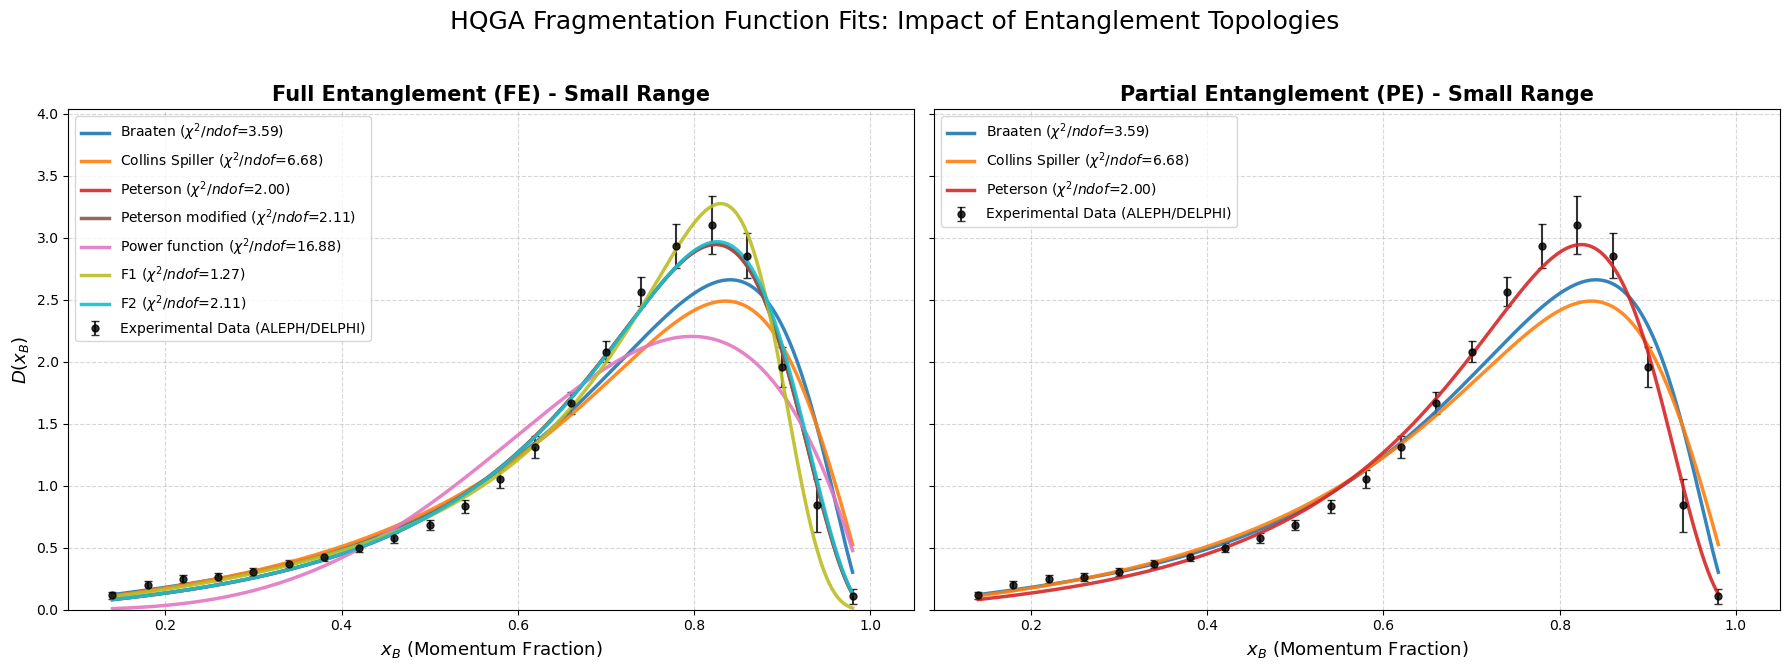

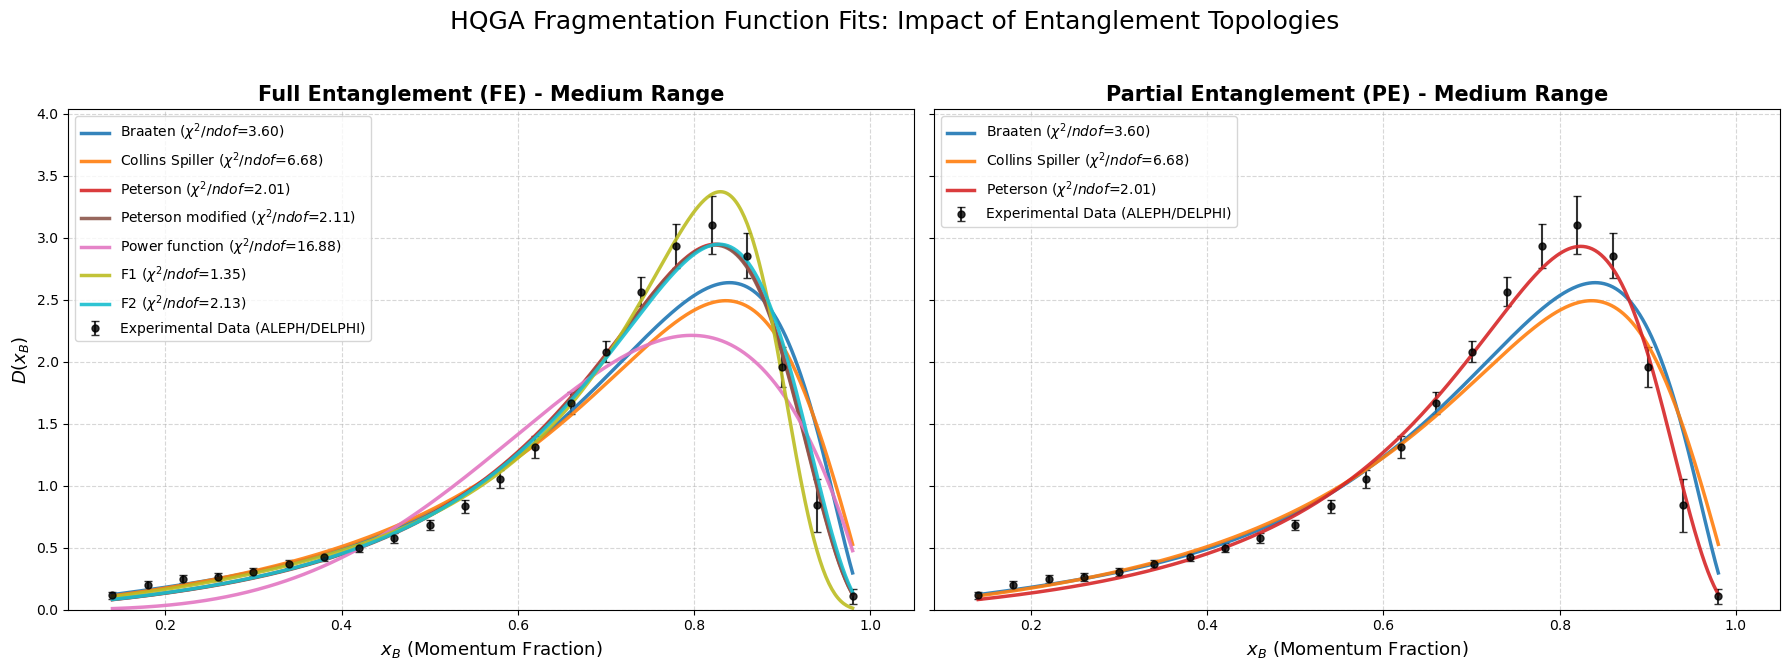

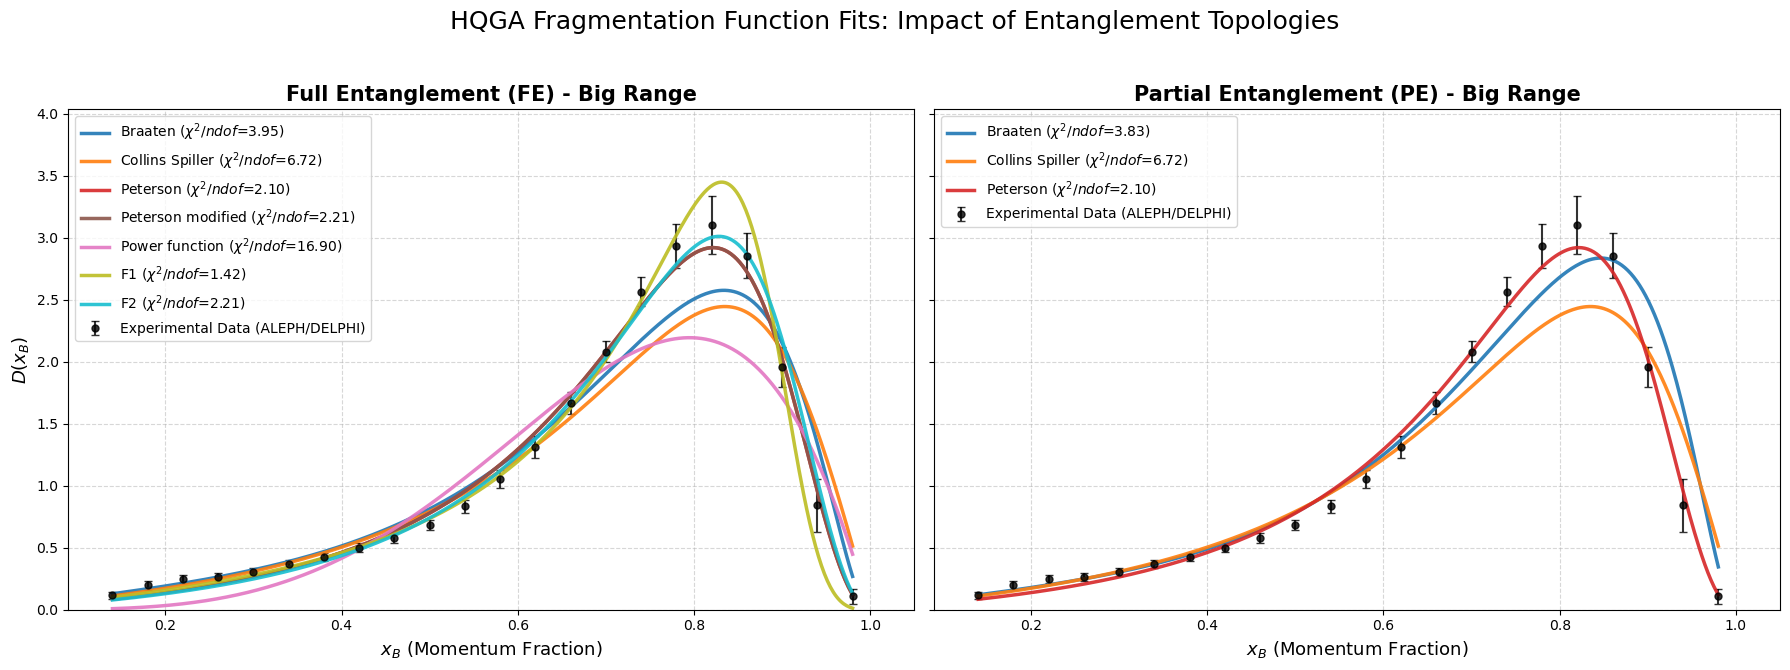

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


models_dict = {
    "Braaten": Braaten, 
    "Collins_Spiller": collins_spiller,
    "Peterson": Peterson,
    
    "Peterson_modified": peterson_mod,
    "Power_function": power_function,
    "F1": f1,
    "F2": f2
}

directorios_FE = ["resultados_tfm", "resultados_tfm_3params"]
directorios_PE = ["resultados_tfm_2_PE", "resultados_tfm_3_PE"]
rangos = ["Small", "Medium", "Big"]

z_plot = np.linspace(min(z_data), max(z_data), 500)
colores = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))

def extraer_mejor_ajuste(model_name, current_range, lista_directorios):
    """Busca el archivo del modelo en los directorios indicados y devuelve el mejor chi2 y theta."""
    filepath = None
    for d in lista_directorios:
        temp_path = f"{d}/resultados_{model_name}_{current_range}.pkl"
        if os.path.exists(temp_path):
            filepath = temp_path
            break
            
    if filepath is None:
        return None  
        
    try:
        with open(filepath, 'rb') as f:
            results = pickle.load(f)
            
        if 'qga' in results: 
            chi2_array = np.array(results['qga']['best_chi2'])
            best_idx = np.argmin(chi2_array)
            return chi2_array[best_idx], results['qga']['best_theta'][best_idx]
            
        elif 'QGA' in results: # Formato antiguo
            chi2_array = np.array(results['QGA']['chi2'])
            best_idx = np.argmin(chi2_array)
            
            param_keys = [k for k in results['QGA'].keys() 
                          if k not in ['chi2', 'gens_to_target', 'history', 'best_binary'] 
                          and not k.startswith('C_') and 'historial' not in k.lower()]
            
            if 'N' in param_keys:
                param_keys.remove('N')
                param_keys.insert(0, 'N')
                
            best_theta = [results['QGA'][k][best_idx] for k in param_keys]
            return chi2_array[best_idx], best_theta
            
    except Exception as e:
        print(f"Error procesando {model_name} en {filepath}: {e}")
        
    return None


for current_range in rangos:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    for ax in axes:
        ax.errorbar(z_data, y_data, yerr=sigma_data, fmt='ko', 
                    markersize=5, capsize=3, alpha=0.8, label='Experimental Data (ALEPH/DELPHI)')
    
    for i, (model_name, model_func) in enumerate(models_dict.items()):
        
        datos_FE = extraer_mejor_ajuste(model_name, current_range, directorios_FE)
        if datos_FE:
            best_chi2_FE, best_theta_FE = datos_FE
            ndof_FE = len(z_data) - len(best_theta_FE)
            chi2_ndof_FE = best_chi2_FE / ndof_FE
            y_fit_FE = model_func(z_plot, *best_theta_FE)
            
            axes[0].plot(z_plot, y_fit_FE, color=colores[i], linewidth=2.5, alpha=0.9,
                         label=f'{model_name.replace("_", " ")} ($\chi^2/ndof$={chi2_ndof_FE:.2f})')

        datos_PE = extraer_mejor_ajuste(model_name, current_range, directorios_PE)
        if datos_PE:
            best_chi2_PE, best_theta_PE = datos_PE
            ndof_PE = len(z_data) - len(best_theta_PE)
            chi2_ndof_PE = best_chi2_PE / ndof_PE
            y_fit_PE = model_func(z_plot, *best_theta_PE)
            
            axes[1].plot(z_plot, y_fit_PE, color=colores[i], linewidth=2.5, alpha=0.9,
                         label=f'{model_name.replace("_", " ")} ($\chi^2/ndof$={chi2_ndof_PE:.2f})')

    axes[0].set_title(f'Full Entanglement (FE) - {current_range} Range', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('$x_B$ (Momentum Fraction)', fontsize=13)
    axes[0].set_ylabel('$D(x_B)$', fontsize=13)
    axes[0].set_xlim(min(z_data) - 0.05, 1.05)
    axes[0].set_ylim(0, max(y_data) * 1.3)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left', fontsize=10, frameon=True)

    axes[1].set_title(f'Partial Entanglement (PE) - {current_range} Range', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('$x_B$ (Momentum Fraction)', fontsize=13)
    axes[1].set_xlim(min(z_data) - 0.05, 1.05)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper left', fontsize=10, frameon=True)

    plt.suptitle(f'HQGA Fragmentation Function Fits: Impact of Entanglement Topologies', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que el suptitle no se superponga
    plt.show()